# Variables & Outliers — EDA for the price model

This notebook documents the data that feeds the price-estimation model, in three parts:

1. **The schema of the raw variables** — every column loaded from the DB, its type, how many values are missing, its range.
2. **The outliers** — the cleaning stages that decide which listings are excluded from training, in the exact order the pipeline runs them: `basic_filters` → `drop_duplicate_listings` → the IQR/Tukey fence, with `repair_price_magnitude` correcting ×1000 currency mixups *before* the fence drops anything. Visualised so the fliers on the plots are the rows actually discarded, not the ones that get repaired and kept.
3. **The derived features** — the columns the model *actually* trains on, including the ones built on the fly from text (`neighborhood`, `delegation`, the `land_*` flags) that are not stored in the DB.

It reuses the **exact same functions** as the training pipeline — `basic_filters`, `drop_duplicate_listings`, `compute_outlier_bounds`, `repair_price_magnitude`, `apply_outlier_bounds` (from `prepare_training_data.py`) and `to_feature_frame` (from `features.py`) — in the same order as `clean_for_training`, so what you see here matches what the model actually trains on, with no separate copy of the logic that could drift.

### How to run
- Make sure the stack is up (`docker compose up -d`) so Postgres is reachable.
- Requirements on your host: `pip install pandas numpy matplotlib psycopg2-binary`
- Run the cells top to bottom.

> The DB connection targets `127.0.0.1:5434` — the address docker-compose publishes Postgres on for the host. (Inside the container it's `db:5432`; that hostname only resolves within the docker network, so it won't work from here.)

## 0. Setup & imports

In [4]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline
import psycopg2

# Make the `scraper` package importable so we reuse the SAME cleaning code the
# model training uses (no drift between this notebook and production).
REPO_ROOT = Path.cwd()
while REPO_ROOT != REPO_ROOT.parent and not (REPO_ROOT / "scraper").is_dir():
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT))

from scraper.ml.prepare_training_data import (
    FEATURE_COLUMNS,
    basic_filters,
    drop_duplicate_listings,
    compute_outlier_bounds,
    repair_price_magnitude,
    apply_outlier_bounds,
    MIN_SALE_PRICE,
    MIN_RENT_PRICE,
    MIN_OUTLIER_GROUP_SIZE,
)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)
print("repo root:", REPO_ROOT)

repo root: c:\Users\ASUS\Desktop\rews


## 1. Connect to the database and load the raw listings

Same query as `load_raw_properties()`: one row per ad (the latest scrape of each `source + ad_id`).

In [5]:
# Read the DB password from .env, but force host/port to the host-published
# address (the .env values `db:5432` only resolve inside the docker network).
def read_env(path):
    env = {}
    p = Path(path)
    if p.exists():
        for line in p.read_text(encoding="utf-8").splitlines():
            line = line.strip()
            if line and not line.startswith("#") and "=" in line:
                k, v = line.split("=", 1)
                env[k.strip()] = v.strip()
    return env

_env = read_env(REPO_ROOT / ".env")
DB = dict(
    host="127.0.0.1",
    port=5434,
    dbname=_env.get("DB_NAME", "realestate"),
    user=_env.get("DB_USER", "postgres"),
    password=_env.get("DB_PASSWORD", "postgres"),
)

query = f"""
    SELECT DISTINCT ON (source, ad_id) {", ".join(FEATURE_COLUMNS)}
    FROM properties
    ORDER BY source, ad_id, id DESC
"""
with psycopg2.connect(**DB) as conn:
    raw = pd.read_sql(query, conn)

print(f"{len(raw):,} unique listings loaded")
raw.head()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_8304\2548234227.py:29: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  raw = pd.read_sql(query, conn)


17,358 unique listings loaded


,id,source,property_type,listing_type,price,area,governorate,city,address,title,description,bedrooms,garage,furnished,terrace,pool,subcategory
0,51122,expat,house,rent,0.0,NaN,Tunis,Carthage,Carthage,"A LOUER UNE VILLA AVEC JARDIN, PISCINE ET UNE ...",A louer une villa située dans un quartier pres...,4.0,False,True,True,True,house
1,51108,expat,house,rent,0.0,NaN,Ariana,11 Rue Taoufik El Ebdelli,"11 Rue Taoufik El Ebdelli, Ariana 2080",Maison / Villa Tunisie 400 m2,"Villa / Maison avec Jardin et terrasses , 400m...",5.0,False,True,True,True,house
2,51121,expat,house,rent,0.0,NaN,Tunis,Carthage,Carthage,"A louer une villa avec jardin et piscine, en S...","A louer une villa avec jardin et piscine, en S...",3.0,False,True,True,True,house
3,51123,expat,house,rent,0.0,NaN,Tunis,Cité les Pins la marsa,Cité les Pins la marsa,Location maison meublée la marsa,Je loue une maison meublée avec 3 chambres 2sa...,3.0,False,True,True,False,house
4,51095,expat,house,rent,0.0,NaN,Jasmin,Jasmin,Jasmin,Villa de luxe à louer à Sidi El Mahrsi. Surfac...,Location annuelle Villa meublé S+3 avec suite ...,3.0,True,True,True,True,house


## 2. Variable schema (raw source columns)

The raw columns `load_raw_properties()` pulls from the DB — one row per ad — with data-quality signals: dtype, how many values are missing, how many distinct values, and the numeric range. This is where you spot problems (e.g. a price `max` in the trillions = garbage to be filtered later).

These are the *source* columns; not all of them are fed to the model directly:
- `id` / `source` are identifiers, not features.
- `address`, `title`, `description` are free text — the model never sees them raw; they're the input the derived `neighborhood`, `delegation` and `land_*` features are built from (see **Section 6**).

The `bedrooms` and `garage / furnished / terrace / pool` columns are sparse because the source sites often omit them; they have since been **back-filled from the listing text** where possible, so their coverage here is higher than a raw first scrape would show.

In [6]:
def schema_report(df):
    rows = []
    for col in df.columns:
        s = df[col]
        info = {
            "column": col,
            "dtype": str(s.dtype),
            "non_null": int(s.notna().sum()),
            "nulls": int(s.isna().sum()),
            "null_%": round(100 * s.isna().mean(), 1),
            "unique": int(s.nunique(dropna=True)),
        }
        if pd.api.types.is_numeric_dtype(s) and s.notna().any():
            info["min"] = round(float(s.min()), 2)
            info["median"] = round(float(s.median()), 2)
            info["max"] = round(float(s.max()), 2)
        rows.append(info)
    return pd.DataFrame(rows)

schema_report(raw)

,column,dtype,non_null,nulls,null_%,unique,min,median,max
0,id,int64,17358,0,0.0,17358,51094.0,59777.5,6.845600e+04
1,source,str,17358,0,0.0,3,NaN,NaN,NaN
2,property_type,str,17358,0,0.0,5,NaN,NaN,NaN
3,listing_type,str,17358,0,0.0,2,NaN,NaN,NaN
4,price,float64,17358,0,0.0,1878,-3.0,1823.5,1.111111e+14
5,area,float64,10554,6804,39.2,1697,1.0,315.0,6.900000e+05
6,governorate,str,17358,0,0.0,44,NaN,NaN,NaN
7,city,str,17358,0,0.0,235,NaN,NaN,NaN
8,address,str,17358,0,0.0,729,NaN,NaN,NaN
9,title,str,17358,0,0.0,14576,NaN,NaN,NaN


### Category breakdowns
The categorical features the model splits on. Watch for lopsided classes (few offices vs many apartments).

In [7]:
for col in ["source", "listing_type", "property_type", "governorate"]:
    print(f"\n===== {col} =====")
    print(raw[col].value_counts(dropna=False).head(12))


===== source =====
source
tayara     11096
mubawab     6187
expat         75
Name: count, dtype: int64

===== listing_type =====
listing_type
sale    9912
rent    7446
Name: count, dtype: int64

===== property_type =====
property_type
land         6377
apartment    5980
house        2502
office       1413
studio       1086
Name: count, dtype: int64

===== governorate =====
governorate
Tunis        6774
Nabeul       2621
Ariana       2203
Sousse       1656
Ben Arous    1066
Sfax          679
Bizerte       523
Mahdia        377
Manouba       361
Monastir      332
Médenine      288
Zaghouan       77
Name: count, dtype: int64


## 3. Stage 1 — basic filters, then de-duplication

Two row-dropping steps run before the fence, neither of which needs group statistics:

- **`basic_filters()`** drops rows that can teach the model nothing: missing required fields, non-positive area, **placeholder prices** (a sale under 1000 TND is "price on request", not a real price; rent under 1 TND), and rent listings priced per night/week (vacation lets — a nightly price is a wrong *target* for a monthly-rent model). The exact thresholds live in `MIN_SALE_PRICE` / `MIN_RENT_PRICE`.
- **`drop_duplicate_listings()`** collapses reposts and cross-posts (the same property re-listed under a fresh `ad_id`, or published on both Tayara and Mubawab). Left in, they double-weight those properties and leak across a train/test split. This runs *before* the fence so the group quantiles are computed on distinct properties.

In [8]:
before = len(raw)
filtered = basic_filters(raw)
after = len(filtered)
print(f"Stage 1: {before:,} -> {after:,}   ({before - after:,} rows dropped)")

# Why rows get dropped (reasons overlap, so these are indicative counts, not a
# partition — a row can be both missing-area and a placeholder price).
r = raw
breakdown = pd.DataFrame({
    "reason": [
        "missing price / area / governorate",
        "area <= 0",
        f"sale price <= {MIN_SALE_PRICE} (placeholder)",
        f"rent price <= {MIN_RENT_PRICE} (placeholder)",
    ],
    "rows_matching": [
        int(r[["price", "area", "governorate"]].isna().any(axis=1).sum()),
        int((r["area"].fillna(0) <= 0).sum()),
        int(((r["listing_type"] == "sale") & (r["price"].fillna(0) <= MIN_SALE_PRICE)).sum()),
        int(((r["listing_type"] != "sale") & (r["price"].fillna(0) <= MIN_RENT_PRICE)).sum()),
    ],
})
breakdown

Stage 1: 17,358 -> 7,919   (9,439 rows dropped)


,reason,rows_matching
0,missing price / area / governorate,6804
1,area <= 0,6804
2,sale price <= 1000 (placeholder),3099
3,rent price <= 1 (placeholder),1071


In [9]:
# De-duplication (still Stage 1): collapse reposts / cross-posts before the fence.
# `filtered` carries through to every cell below, so from here on it is the
# distinct-properties frame the fence is computed on.
before = len(filtered)
filtered = drop_duplicate_listings(filtered)
print(f"De-dup: {before:,} -> {len(filtered):,}   ({before - len(filtered):,} duplicate rows dropped)")

De-dup: 7,919 -> 6,970   (949 duplicate rows dropped)


## 4. Stage 2 — the outlier fence (aberrations)

For each `(listing_type, property_type)` group, `compute_outlier_bounds()` builds a **Tukey / IQR fence** on `log(price / area)`:

```
lower = Q1 - 1.5 * IQR      upper = Q3 + 1.5 * IQR      (IQR = Q3 - Q1)
```

Anything outside its group's fence is an outlier. Groups smaller than `MIN_OUTLIER_GROUP_SIZE` (20 rows) can't give trustworthy quartiles, so instead of an unbounded fence they **fall back to their whole `listing_type`'s fence** — wider than a per-type fence, but still catches the orders-of-magnitude garbage (e.g. `sale / office`, 9 rows, gets the sale-wide fence rather than `-inf / inf`).

The fence isn't applied yet, though. First `repair_price_magnitude()` (next cell) rescues the ×1000 currency mixups — a price entered in millimes instead of dinars lands ~3 orders of magnitude outside the fence, and dividing it by 1000 usually puts it right back inside, so the row is **corrected and kept** rather than discarded. Only after that does `apply_outlier_bounds()` drop whatever is still outside. That ordering is why the fliers on the plots below are the *genuine* drops, not the repairable ones.

> **Note on method:** the bounds are computed on the de-duplicated, **pre-repair** rows — exactly as `clean_for_training` does. Production (`train_price_model.py`) additionally splits train/test *first* and fits the fence on the training fold only, to avoid leakage. Here we compute it on all filtered rows purely to **visualise** the fence — this notebook is for looking, not training.

In [10]:
filtered = filtered.copy()
filtered["log_ppm2"] = np.log(filtered["price"] / filtered["area"])

bounds = compute_outlier_bounds(filtered)
bounds

lower      upper
listing_type property_type                     
rent         apartment      1.706342   3.957819
             house          1.243477   4.186304
             land           0.754242   3.950678
             office        -3.260218   7.097684
             studio         1.766957   4.276539
sale         apartment      6.970427   9.105734
             house          5.216178   9.757605
             land           2.560653   9.861091
             office         2.771863  10.958618
             studio         6.902657   9.473885

In [11]:
# Repair ×1000 currency mixups using the fence just computed, BEFORE dropping.
# repair_price_magnitude only rewrites `price` where dividing (or multiplying) by
# 1000 lands the row back inside its group's fence; every other row is untouched.
# We reassign into `filtered` and recompute log_ppm2, so every plot/table below
# reflects the repaired prices — the fliers you then see are the rows STILL
# outside the fence, i.e. the ones apply_outlier_bounds actually drops.
before_prices = filtered["price"].to_numpy(copy=True)
filtered = repair_price_magnitude(filtered, bounds)
n_repaired = int((filtered["price"].to_numpy() != before_prices).sum())
filtered["log_ppm2"] = np.log(filtered["price"] / filtered["area"])
print(f"Repair: {n_repaired:,} ×1000 price mixups corrected and kept (not dropped)")

Repair: 249 ×1000 price mixups corrected and kept (not dropped)


In [12]:
# `filtered` is now post-dedup + post-repair, so these are the rows the training
# pipeline actually discards — the repairable ×1000 mixups are no longer counted.
kept = apply_outlier_bounds(filtered, bounds)
n_out = len(filtered) - len(kept)
print(f"Stage 2: {len(filtered):,} -> {len(kept):,}   ({n_out:,} rows dropped as outliers / aberrations, after repair)")

Stage 2: 6,970 -> 6,770   (200 rows dropped as outliers / aberrations, after repair)


### How many outliers per group
Which property types have the most aberrant prices, in absolute count and as a percentage.

In [13]:
joined = filtered.join(bounds, on=["listing_type", "property_type"])
joined["is_outlier"] = ~joined["log_ppm2"].between(
    joined["lower"].fillna(-np.inf), joined["upper"].fillna(np.inf)
)

per_group = (
    joined.groupby(["listing_type", "property_type"])
          .agg(n=("id", "size"), outliers=("is_outlier", "sum"))
)
per_group["outlier_%"] = (100 * per_group["outliers"] / per_group["n"]).round(1)
per_group.sort_values("outliers", ascending=False)

n  outliers  outlier_%
listing_type property_type                           
rent         studio          492        54       11.0
sale         house           609        45        7.4
             apartment      1222        37        3.0
rent         apartment       840        27        3.2
             house           281        20        7.1
             land             46         9       19.6
sale         studio           79         5        6.3
             land           3353         3        0.1
rent         office           39         0        0.0
sale         office            9         0        0.0

## 5. Visualise the outliers

Everything below runs on the deduped **and repaired** `filtered` frame, so the aberrations shown are the ones that survive `repair_price_magnitude` and are genuinely dropped — the ×1000 currency mixups have already been pulled back inside their fence and won't appear as fliers.

### 5a. Boxplot per group
Each box is the "normal" middle 50% of `log(price/area)`; the dots beyond the whiskers are the aberrant listings. Only groups with >= 20 rows (i.e. the ones that actually get filtered) are shown.

> The whiskers here are matplotlib's *own* 1.5×IQR, recomputed per group on the data plotted — a close but not exact stand-in for the pipeline's fence (which is fit on the pre-repair rows, and for tiny groups falls back to the listing-type fence). For the **exact** per-group outlier counts and fence, use the table in §4 and the histogram in §5b, which apply the real `bounds`.

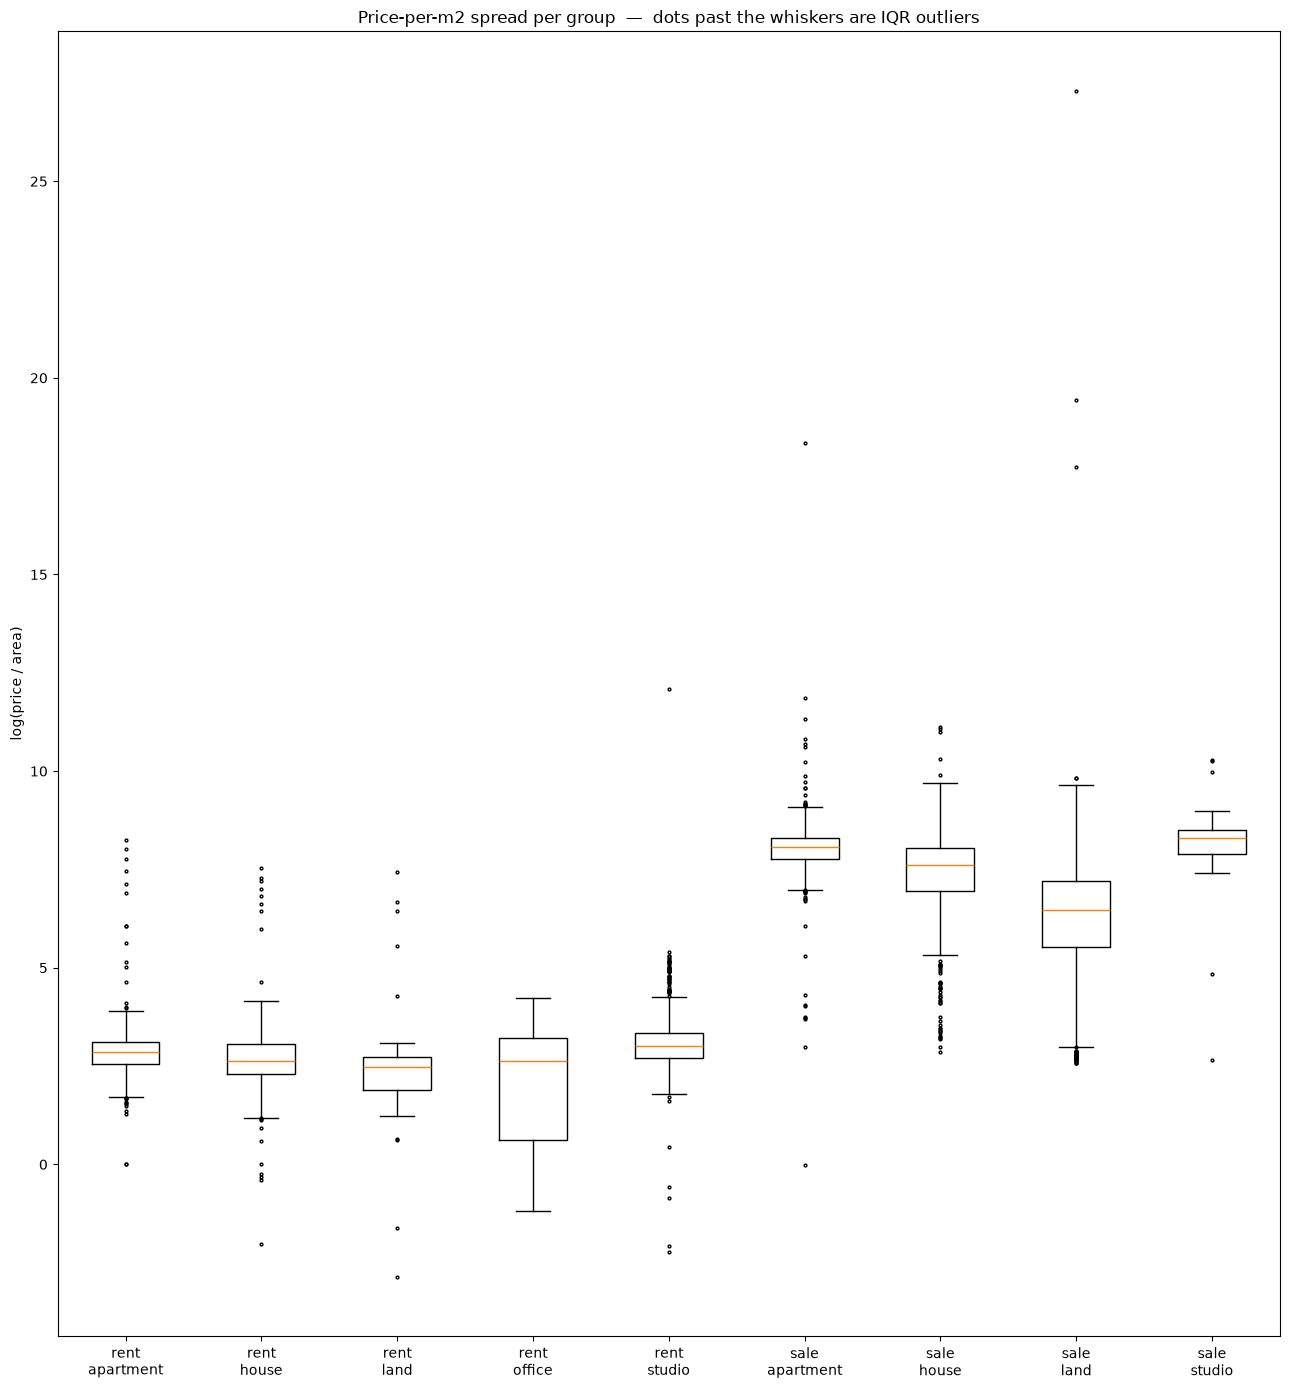

In [14]:
labels, data = [], []
for (lt, pt), g in filtered.groupby(["listing_type", "property_type"]):
    if len(g) >= MIN_OUTLIER_GROUP_SIZE:
        labels.append(f"{lt}\n{pt}")
        data.append(g["log_ppm2"].to_numpy())

fig, ax = plt.subplots(figsize=(13, 14 ))
ax.boxplot(data, tick_labels=labels, showfliers=True, flierprops=dict(marker=".", markersize=4))
ax.set_ylabel("log(price / area)")
ax.set_title("Price-per-m2 spread per group  —  dots past the whiskers are IQR outliers")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 5b. Histogram with the fence drawn
The red dashed lines are the lower/upper fence for one group. Everything outside them is excluded. Change the arguments to inspect any group.

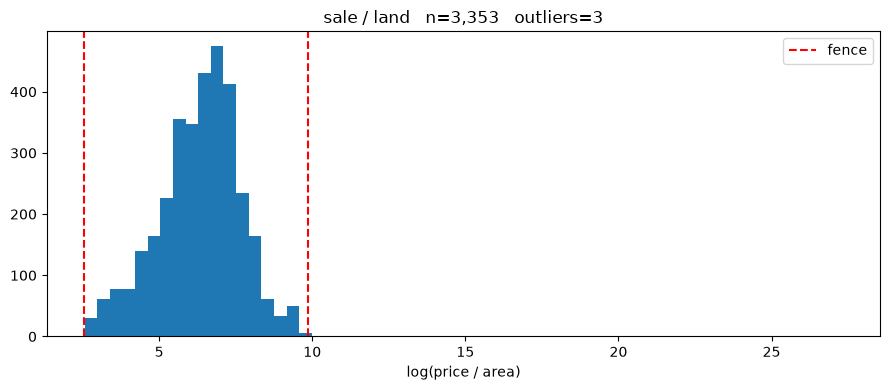

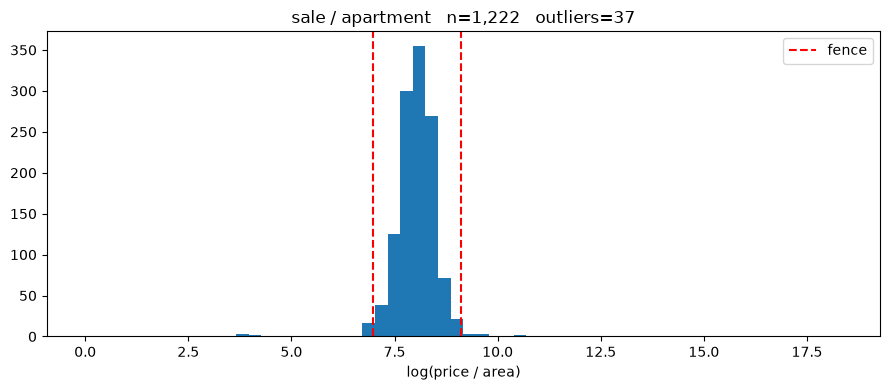

In [15]:
def plot_group(listing_type, property_type, bins=60):
    g = filtered[(filtered.listing_type == listing_type) & (filtered.property_type == property_type)]
    if (listing_type, property_type) not in bounds.index:
        print("no fence for this group (too small / not present)")
        return
    lo, hi = bounds.loc[(listing_type, property_type), ["lower", "upper"]]
    n_out = int((~g["log_ppm2"].between(lo, hi)).sum())

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.hist(g["log_ppm2"], bins=bins)
    if np.isfinite(lo):
        ax.axvline(lo, color="red", ls="--", label="fence")
    if np.isfinite(hi):
        ax.axvline(hi, color="red", ls="--")
    ax.set_title(f"{listing_type} / {property_type}   n={len(g):,}   outliers={n_out:,}")
    ax.set_xlabel("log(price / area)")
    ax.legend()
    plt.tight_layout()
    plt.show()

plot_group("sale", "land")
plot_group("sale", "apartment")

### 5c. The most extreme excluded listings
Sorted by price-per-m2 so the obvious garbage (currency mixups, typos) surfaces at the top. This is the table to eyeball if you're deciding whether some aberrations are *correctable* rather than junk.

In [16]:
outliers = joined[joined["is_outlier"]].copy()
outliers["price_per_m2"] = (outliers["price"] / outliers["area"]).round(1)

# The fence is applied to log(price / area). Convert each group's log-bounds
# back to readable price-per-m2 values so you can compare them to the row's own
# price_per_m2, and record WHICH side of the fence the row broke.
outliers["fence_low_ppm2"] = np.exp(outliers["lower"]).round(1)
outliers["fence_high_ppm2"] = np.exp(outliers["upper"]).round(1)
outliers["why_outlier"] = np.where(
    outliers["log_ppm2"] > outliers["upper"], "price/m2 too HIGH (> fence_high)",
    np.where(outliers["log_ppm2"] < outliers["lower"], "price/m2 too LOW (< fence_low)", ""),
)

# NOTE: the fence tests the RATIO price/area, so "too HIGH" can mean an inflated
# price OR an abnormally tiny area (e.g. area = 3 m2), and "too LOW" often means
# a price entered in the wrong currency unit (dinars vs millimes). The column
# tells you which side broke; eyeball area + price to see which value is at fault.
cols = ["id", "source", "listing_type", "property_type", "governorate",
        "area", "price", "price_per_m2", "fence_low_ppm2", "fence_high_ppm2", "why_outlier"]
all_outliers = outliers.sort_values("price_per_m2", ascending=False)[cols].reset_index(drop=True)

print(f"{len(all_outliers):,} outlier listings")
print(all_outliers["why_outlier"].value_counts().to_string())

# Plain numbers instead of 1.11e+14 scientific notation, and show every row.
with pd.option_context("display.max_rows", None, "display.float_format", lambda v: f"{v:,.1f}"):
    display(all_outliers)

200 outlier listings
why_outlier
price/m2 too HIGH (> fence_high)    105
price/m2 too LOW (< fence_low)       95


,id,source,listing_type,property_type,governorate,area,price,price_per_m2,fence_low_ppm2,fence_high_ppm2,why_outlier
0,58786,tayara,sale,land,Ariana,154.0,"111,111,114,000,000.0","721,500,740,259.7",12.9,"19,169.8",price/m2 too HIGH (> fence_high)
1,60354,tayara,sale,land,Nabeul,400.0,"111,111,110,000.0","277,777,775.0",12.9,"19,169.8",price/m2 too HIGH (> fence_high)
2,58319,tayara,sale,apartment,Tunis,3.0,"280,000,000.0","93,333,333.3","1,064.7","9,006.8",price/m2 too HIGH (> fence_high)
3,60829,tayara,sale,land,Nabeul,220.0,"11,111,111,000.0","50,505,050.0",12.9,"19,169.8",price/m2 too HIGH (> fence_high)
4,52657,tayara,rent,studio,Ariana,700.0,"123,456,780.0","176,366.8",5.9,72.0,price/m2 too HIGH (> fence_high)
5,58231,tayara,sale,apartment,Sousse,3.0,"420,000.0","140,000.0","1,064.7","9,006.8",price/m2 too HIGH (> fence_high)
6,57397,tayara,sale,apartment,Ariana,6.0,"495,000.0","82,500.0","1,064.7","9,006.8",price/m2 too HIGH (> fence_high)
7,61875,mubawab,sale,house,Tunis,480.0,"32,500,000.0","67,708.3",184.2,"17,285.2",price/m2 too HIGH (> fence_high)
8,57494,tayara,sale,house,Tunis,15.0,"975,000.0","65,000.0",184.2,"17,285.2",price/m2 too HIGH (> fence_high)
9,61992,mubawab,sale,house,Tunis,300.0,"18,000,000.0","60,000.0",184.2,"17,285.2",price/m2 too HIGH (> fence_high)


## 6. The features the model actually trains on (derived)

Sections 2–5 describe the *raw* rows. But the model doesn't train on those columns as-is: `to_feature_frame()` (the single function shared by training and serving) turns each cleaned row into the model's real input, adding three kinds of feature that are **not stored in the DB** and are recomputed every time from the text above:

- **`neighborhood`** — a canonical Grand-Tunis micro-area resolved from `address`/`city`/`title`/`description` (`scraper/neighborhood.py`). City alone isn't granular enough — most Tunis rows just say `city = "Tunis"`.
- **`delegation`** — a town-level location, one step finer than `governorate` (`scraper/governorate.py`). It covers the rural towns (mostly land) that the urban neighborhood gazetteer misses.
- **`land_*`** — 11 land-use / legal / servicing flags (agricultural, titled, serviced, beachfront, constructible…) parsed from the listing text (`scraper/land_features.py`). They're `NaN` for every non-land row, so the model simply ignores them there; for land they carry the price signal that isn't in any structured column.

Running `to_feature_frame` on the cleaned rows below shows the full feature matrix the model receives — categoricals first (as the pipeline's `ColumnTransformer` expects), then numerics.

In [17]:
from scraper.ml.features import to_feature_frame, ALL_FEATURES, CATEGORICAL_FEATURES, NUMERIC_FEATURES

# `kept` (the post-outlier-fence rows) is exactly what train_price_model.py feeds in.
X = to_feature_frame(kept)

print(f"{len(ALL_FEATURES)} model features = "
      f"{len(CATEGORICAL_FEATURES)} categorical + {len(NUMERIC_FEATURES)} numeric")
print("categorical:", CATEGORICAL_FEATURES)
print("numeric    :", NUMERIC_FEATURES)
schema_report(X)

33 model features = 7 categorical + 25 numeric
categorical: ['listing_type', 'property_type', 'governorate', 'city', 'subcategory', 'neighborhood', 'delegation']
numeric    : ['area', 'bedrooms', 'garage', 'furnished', 'terrace', 'pool', 'land_agricole', 'land_industriel', 'land_touristique', 'land_residentiel', 'land_titled', 'land_serviced', 'land_beachfront', 'land_fenced', 'land_lotissement', 'land_road_access', 'land_constructible', 'bldg_neuf', 'bldg_renove', 'bldg_haut_standing', 'bldg_vue_mer', 'bldg_chauffage', 'bldg_ascenseur', 'bldg_climatisation', 'bldg_etage']


,column,dtype,non_null,nulls,null_%,unique,min,median,max
0,listing_type,object,6770,0,0.0,2,NaN,NaN,NaN
1,property_type,object,6770,0,0.0,5,NaN,NaN,NaN
2,governorate,object,6770,0,0.0,26,NaN,NaN,NaN
3,city,object,6770,0,0.0,154,NaN,NaN,NaN
4,subcategory,object,6770,0,0.0,5,NaN,NaN,NaN
5,neighborhood,object,5236,1534,22.7,121,NaN,NaN,NaN
6,delegation,object,6766,4,0.1,231,NaN,NaN,NaN
7,text,str,6770,0,0.0,6743,NaN,NaN,NaN
8,area,float64,6770,0,0.0,1326,1.0,281.0,690000.0
9,bedrooms,float64,1694,5076,75.0,15,0.0,3.0,15.0


In [18]:
# Coverage of the derived location features, and how often each land_* flag fires
# among land rows (they are NaN - hence excluded here - for every non-land row).
print(f"neighborhood resolved: {X['neighborhood'].notna().mean()*100:4.0f}%   ({X['neighborhood'].nunique()} distinct)")
print(f"delegation resolved  : {X['delegation'].notna().mean()*100:4.0f}%   ({X['delegation'].nunique()} distinct)")

land_flags = [c for c in NUMERIC_FEATURES if c.startswith("land_")]
is_land = X["property_type"] == "land"
cov = (X.loc[is_land, land_flags] == 1).mean().mul(100).round(0).astype(int)
cov = cov.sort_values(ascending=False).rename("pct_of_land_rows_where_flag_is_1")
cov.to_frame()

neighborhood resolved:   77%   (121 distinct)
delegation resolved  :  100%   (231 distinct)


,pct_of_land_rows_where_flag_is_1
land_residentiel,44
land_titled,32
land_road_access,31
land_beachfront,16
land_agricole,14
land_serviced,11
land_fenced,7
land_constructible,7
land_lotissement,6
land_touristique,5


## Summary

- **Section 2** is the *raw variable schema* — the source columns, their types, missingness and ranges.
- **Sections 3–5** are the *outliers* — the full cleaning chain (`basic_filters` → `drop_duplicate_listings` → `repair_price_magnitude` → the IQR fence) and how the fence flags aberrant prices, as tables and plots. Because repair runs before the fence, the fliers shown are the rows genuinely dropped, not the ×1000 mixups that get corrected and kept.
- **Section 6** is the *derived feature matrix* — what `to_feature_frame` actually hands the model, including the on-the-fly `neighborhood`, `delegation` and `land_*` features.

Nothing here modifies the database; it all runs on an in-memory copy, exactly like the training pipeline. To change what gets **excluded**, edit the thresholds in `scraper/ml/prepare_training_data.py` (`MIN_SALE_PRICE`, `MIN_OUTLIER_GROUP_SIZE`, or the `iqr_multiplier`). To change what **features** the model sees, edit `scraper/ml/features.py` (and retrain — the pipeline addresses columns positionally, so a feature change needs a fresh artifact).